In [1]:
"""
The Goal of this notebook:
- initialize the clouds rainforest style


Verification:
-show all renders of the clouds
--big picture
--close up view
(static is okay)
--must still block camera ray

API:
-inputs:
-- go through SimConfig (can be consumed by Sim Kernel)
-- define what is needed (keep running in sim kernel in mind, should tie in SimConfig, can be extended, can be passed as function)
-- (instead of passing target area, where target area is currently parsed send this function)

-output:
-- list[Cloud]

use defaults:
- element size: min 1km
- [4,20] km height sampling
- [1,100] km range sampling
- minimal Area for "cloud", since clouds are boolean and block directly
-> 1x4    = 4 m2
-> 4x100  = 400m2
-> 20x100 = 2000m2
- clouds are disks, arc length is given by range, height by height
- formation start (pos)
- formation end (pos)

"""

'\nThe Goal of this notebook:\n- initialize the clouds rainforest style\n\n\nVerification:\n-show all renders of the clouds\n--big picture\n--close up view\n(static is okay)\n--must still block camera ray\n\nAPI:\n-inputs:\n-- go through SimConfig (can be consumed by Sim Kernel)\n-- define what is needed (keep running in sim kernel in mind, should tie in SimConfig, can be extended, can be passed as function)\n-- (instead of passing target area, where target area is currently parsed send this function)\n\n-output:\n-- list[Cloud]\n\nuse defaults:\n- element size: min 1km\n- [4,20] km height sampling\n- [1,100] km range sampling\n- minimal Area for "cloud", since clouds are boolean and block directly\n-> 1x4    = 4 m2\n-> 4x100  = 400m2\n-> 20x100 = 2000m2\n- clouds are disks, arc length is given by range, height by height\n- formation start (pos)\n- formation end (pos)\n\n'

In [2]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
import json
import sys

import numpy as np
# Resolve project/backend roots from notebook location.
_cwd = Path.cwd().resolve()
_candidates = [_cwd, _cwd.parent, _cwd.parent.parent, _cwd.parent.parent.parent]
project_root = None
for p in _candidates:
    if (p / "backend").exists():
        project_root = p
        break
if project_root is None:
    raise RuntimeError("Could not resolve project root containing backend/.")

backend_root = project_root / "backend"
if str(backend_root) not in sys.path:
    sys.path.insert(0, str(backend_root))

_s01_dir = backend_root / "notebooks" / "s01"
if str(_s01_dir) not in sys.path:
    sys.path.insert(0, str(_s01_dir))

In [3]:
import importlib

import numpy as np

from environment_definition.constants import ureg
from environment_definition.constants.SIMULATION import GeodeticLonLat
from s01_utils import cloud_formation, cloud_verification

importlib.reload(cloud_formation)
importlib.reload(cloud_verification)

# Formation corridor in geodetic (lat, lon); clouds extend along the orbit-disk path.
formation_start = GeodeticLonLat(lat=60.0 * ureg.deg, lon=0.0 * ureg.deg)
formation_end = GeodeticLonLat(lat=85.0 * ureg.deg, lon=180.0 * ureg.deg)

cloud_base_altitude_bounds = (4, 12) * ureg.km
cloud_thickness_bounds = (1, 16) * ureg.km
max_top_altitude = 20 * ureg.km
cloud_range_bounds = (1, 100) * ureg.km
cloud_number_bounds = (50, 200)

RNG = np.random.default_rng(42)



In [4]:
clouds = cloud_formation.cloud_formation_generator(
    formation_start=formation_start,
    formation_end=formation_end,
    cloud_base_altitude_bounds=cloud_base_altitude_bounds,
    cloud_thickness_bounds=cloud_thickness_bounds,
    max_top_altitude=max_top_altitude,
    cloud_range_bounds=cloud_range_bounds,
    cloud_number_bounds=cloud_number_bounds,
    rng=RNG,
)

In [5]:
# Gate 3a: structured table + static arc preview (generator output).
cloud_verification.print_cloud_verification_summary(
    clouds,
    formation_start=formation_start,
    formation_end=formation_end,
)


Cloud formation verification summary
  count:      63
  path_km:    3906
  formation:  (60.00, 0.0) -> (85.00, 180.0)
  phi span:   60.956 deg -> 93.712 deg

Structured cloud table
idx  base_km top_km thick_km extent_km start_lat start_lon   phi_lo   phi_hi
  0        7     14        7        80    82.611       0.0   82.561   83.281
  1       10     14        4        83    62.804       0.0   62.648   63.398
  2       12     20        8        10    78.417       0.0   78.342   78.435
  3       11     20        9        78    84.812       0.0   84.777   85.481
  4        8     17        9        13    89.499       0.0   89.495   89.611
  5       12     20        8        38    66.126       0.0   65.983   66.323
  6       11     20        9        67    73.752       0.0   73.649   74.251
  7        6      8        2        46    75.533       0.0   75.440   75.858
  8        4     18       14        55    89.182     180.0   90.824   91.316
  9        9     12        3        84    69.289 

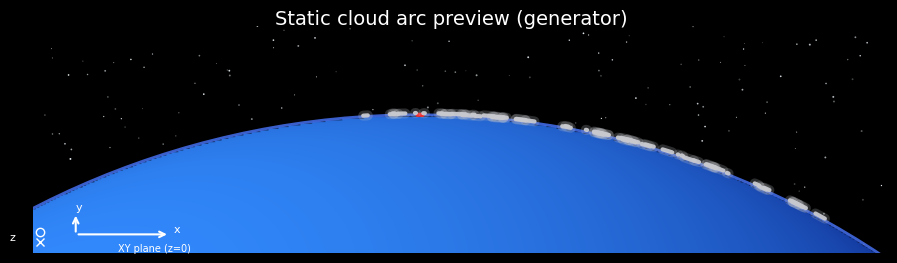

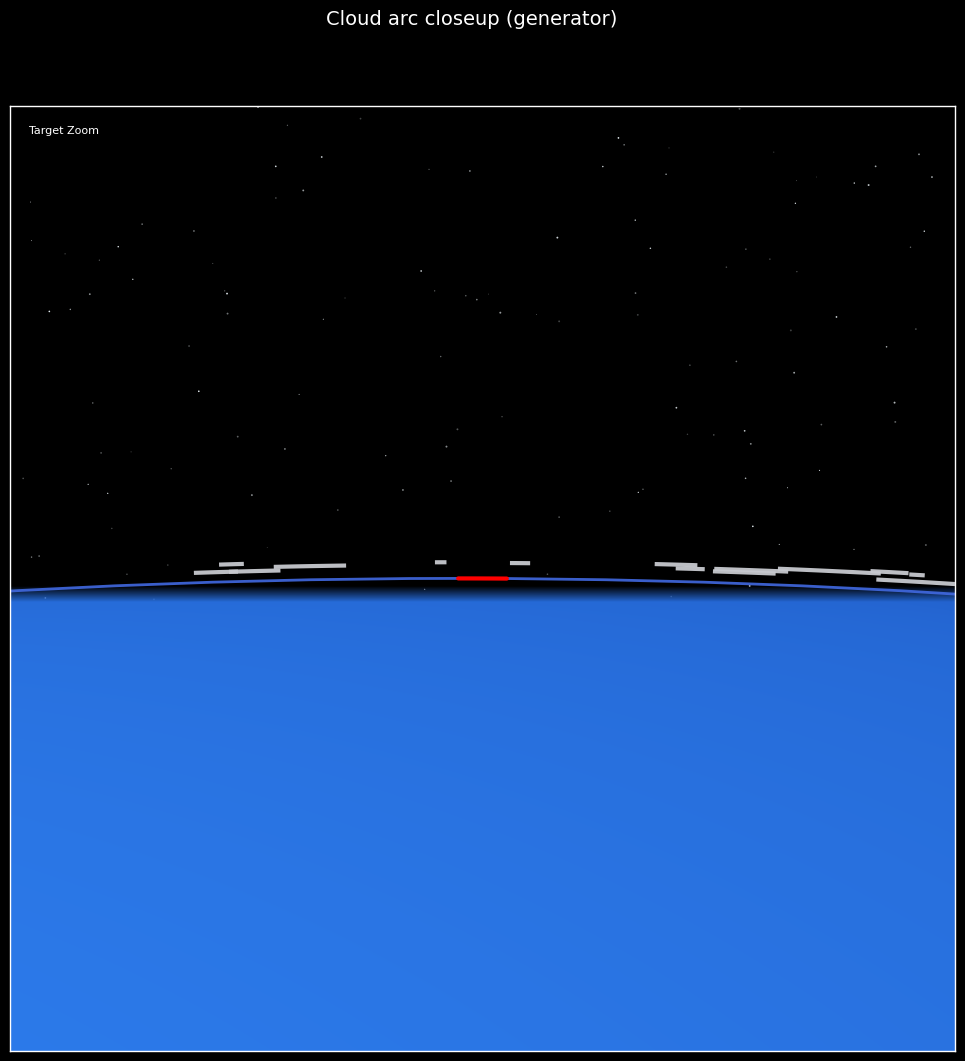

In [6]:

cloud_verification.show_static_preview_from_clouds(clouds)

Running coast episode with generated clouds + target grid...


D:\code\sem-proj-asc\backend\simulation\stepper.py:154: UserWarning: controller_update_interval (1 s) is not an integer multiple of simulation_timestep (0.4 s); using nearest multiple: 0.8 s (2 sim steps).
  self._controller_interval_steps, self._effective_controller_interval_s = resolve_controller_interval_steps(


╭──────────────────────────────────────────────── Simulation info ────────────────────────────────────────────────╮
│  Parameter                                     Value                                                            │
│  episode duration                              851.80 s                                                         │
│  simulation timestep                           0.399906 s                                                       │
│  integration steps                             2130 (+1 state samples)                                          │
│  orbit altitude                                548.22 km                                                        │
│  orbit period                                  5727.9 s                                                         │
│  theta center offset                           90.00 deg                                                        │
│  episode theta start (rel. center)             -28.011 deg                                                      │
│  episode theta end (rel. center)               22.975 deg                                                       │
│  sat motion span scale                         1.050                                                            │
│  sat z offset                                  0.00 deg                                                         │
│  target areas                                  10                                                               │
│  target phi stripe                             85.00 deg .. 89.96 deg                                           │
│  cloud patches                                 63                                                               │
│  render mode                                   headless                                                         │
│  controller mode                               coast                                                            │
│  controller seed                               -                                                                │
│  controller update (configured)                1 s                                                              │
│  controller update (effective)                 0.8 s (2 steps)                                                  │
│  reaction-wheel torque max                     0.1000 N*m                                                       │
│  attitude safety cutoff                        |omega_sat| > 3.00 deg/s -> block opposing torque                │
│  camera kernel backend                         accelerated                                                      │
│  reward shaping                                distance_reward, outer_gate                                      │
│  Camera 1 (primary) - role                     shapes reward (observation line + strip)                         │
│  Camera 1 (primary) - tilt off nadir           0.00 deg                                                         │
│  Camera 1 (primary) - FOV (cross x along)      1.61 deg x 1.20 deg                                              │
│  Camera 1 (primary) - resolution               9344 x 7000 px                                                   │
│  Camera 1 (primary) - pixel pitch              3.20 um                                                          │
│  Camera 1 (primary) - focal length             1067.0 mm                                                        │
│  Camera 1 (primary) - GSD @ 548.2 km           1.644 m                                                          │
│  Camera 1 (primary) - observation line bins    100                                                              │
│  Camera 1 (primary) - strip ray samples        96                                                               │
│  Camera 1 (primary) - sim vertical FOV         1.203 deg                                                        │
│  Camera 1 (primary) - exposure time            not mod

Running simulation: 100%|██████████| 2130/2130 [00:18<00:00, 117.53step/s]


  frames:              2131
  cloud columns:       63
  cloud ray hits:      71217
  target ray hits:     1943
  mean reward:         -98.405
  mean blocked frac:   0.3342
  render bands:        10
  peak blocked frame:  11
[video] archived previous export -> D:\code\sem-proj-asc\backend\notebooks\s01\artifacts\video_archive\008-clouds_coast.mp4


Writing video: 100%|██████████| 948/948 [01:30<00:00, 10.50frame/s]


[mpo_video:after_export] clouds_coast.mp4 (1465136 bytes, codec=h264)
Saved: D:\code\sem-proj-asc\backend\notebooks\s01\artifacts\clouds_coast.mp4
[mpo_video:play] clouds_coast.mp4 (1465136 bytes, codec=h264)


<Figure size 1200x700 with 0 Axes>

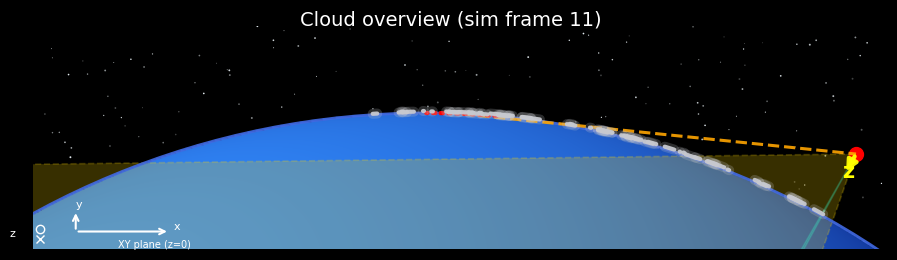

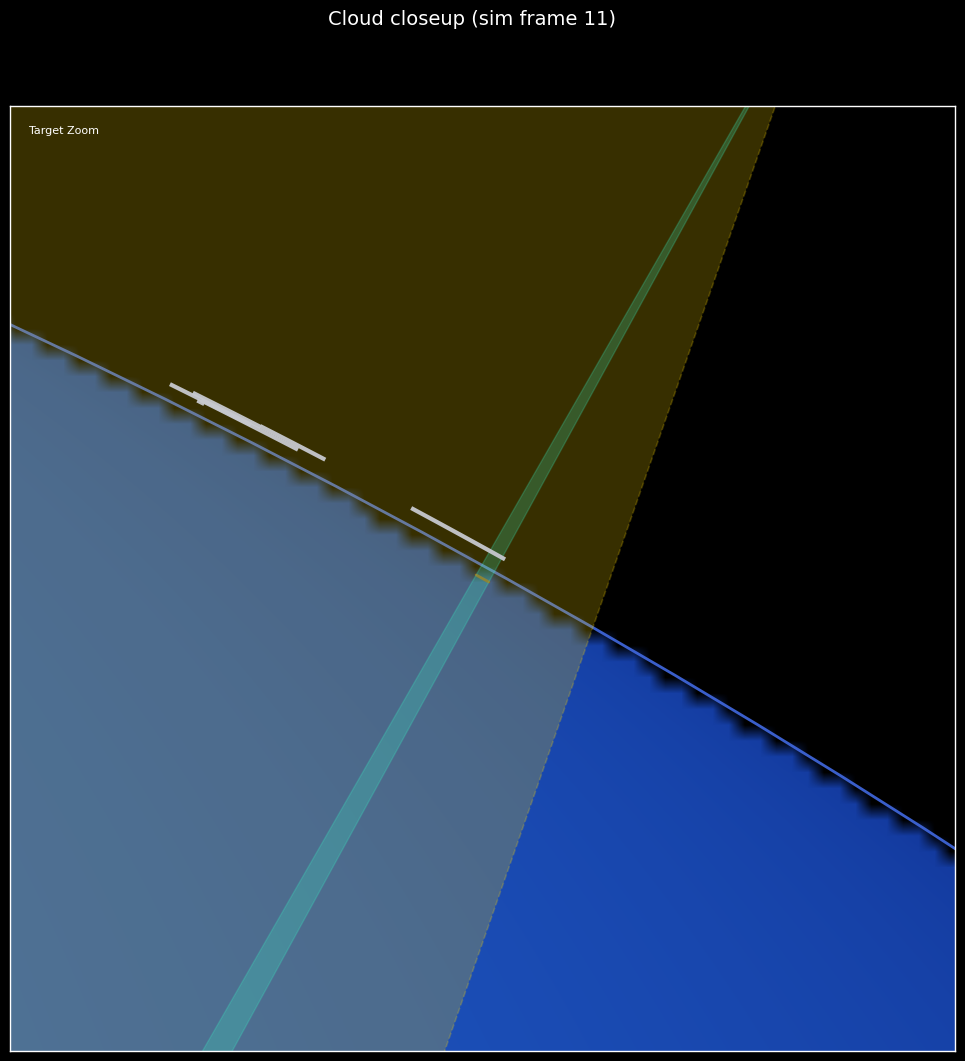

In [7]:
# Gate 3b + E2E: canonical sim (same setup as target grid) -> stats, video, sim-backed panels.
# Reward check: polar-meridian target grid adds target hits alongside cloud occlusion.

from dataclasses import replace

import matplotlib

matplotlib.use("Agg")

import numpy as np

from environment_definition.constants.MISSION import LON_GLOBAL
from environment_definition.constants.SIMULATION import (
    OBSERVATION_CLOUD,
    OBSERVATION_TARGET,
    RenderMode,
    SimulationConfig,
)
from environment_definition.mission_profiles.s01_multiple_targets_fwd_fish import build_setup
from simulation.run_simulation import run_simulation
from utils.geometry.polar_meridian_track import build_target_grid_polar_meridian
from utils.notebook.video import export_and_play_saved_video

ARTIFACT_DIR = backend_root / "notebooks" / "s01" / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

target_size = 20 * ureg.kilometer
spacing = 40 * ureg.kilometer
anchor_lat = 85 * ureg.deg
anchor_lon = 0 * ureg.deg
n_targets = 10
segments = build_target_grid_polar_meridian(
    anchor_lat=anchor_lat,
    anchor_lon=anchor_lon,
    n_targets=n_targets,
    target_size=target_size,
    spacing=spacing,
)
targets = [segment.to_observation_target_area() for segment in segments]

setup = replace(
    build_setup(seed=0, include_cameras=True),
    target_areas=tuple(targets),
    clouds=tuple(clouds),
)

sim_cfg = SimulationConfig(render_mode=RenderMode.HEADLESS, controller_mode="coast")
print("Running coast episode with generated clouds + target grid...")
cloud_series = run_simulation(setup=setup, simulation_config=sim_cfg)

n_cloud_hits = int(np.sum(cloud_series.camera_observation_line_codes == np.int8(OBSERVATION_CLOUD)))
n_target_hits = int(np.sum(cloud_series.camera_observation_line_codes == np.int8(OBSERVATION_TARGET)))
n_cloud_cols = int(cloud_series.cloud_arc_radius_km.shape[1])
print(f"  frames:              {len(cloud_series.t_s)}")
print(f"  cloud columns:       {n_cloud_cols}")
print(f"  cloud ray hits:      {n_cloud_hits}")
print(f"  target ray hits:     {n_target_hits}")
print(f"  mean reward:         {float(np.mean(cloud_series.simulation_reward)):.3f}")
print(f"  mean blocked frac:   {float(np.nanmean(cloud_series.camera_cloud_blocked_fraction)):.4f}")
print(f"  render bands:        {len(cloud_series.metadata.target_region_bounds_deg or ())}")

best_frame = int(np.nanargmax(cloud_series.camera_cloud_blocked_fraction))
print(f"  peak blocked frame:  {best_frame}")

video_path = ARTIFACT_DIR / "clouds_coast.mp4"
export_and_play_saved_video(simulation_series=cloud_series, out_path=video_path)
print(f"Saved: {video_path}")

matplotlib.use("module://matplotlib_inline.backend_inline")
cloud_verification.show_static_panels_from_series(cloud_series, frame_idx=best_frame)
